In [1]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 12

In [3]:
os.makedirs("charts", exist_ok=True)
print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
import os

In [11]:
print(os.getcwd())

/Users/abhishekkumar


In [15]:
os.chdir("/Users/abhishekkumar/Desktop/Stocks analysis project")

In [16]:
print("Current folder:", os.getcwd())

Current folder: /Users/abhishekkumar/Desktop/Stocks analysis project


In [17]:
print("Files on Desktop:", os.listdir())

Files on Desktop: ['Stocks .csv', 'companies.csv']


In [20]:
df = pd.read_csv("Stocks .csv")
df_companies = pd.read_csv("companies.csv")

In [21]:
df = df.merge(df_companies, on="ticker", how="left")

In [22]:
df["date"] = pd.to_datetime(df["date"])

In [23]:
print(f"✅ Data loaded successfully!")
print(f"Total rows : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
print(f"Date range : {df['date'].min()} to {df['date'].max()}")
df.head()

✅ Data loaded successfully!
Total rows : 619,029
Total columns : 11
Date range : 2013-02-08 00:00:00 to 2018-02-07 00:00:00


,id,date,open,high,low,close,volume,ticker,name,sector,industry
0,1,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL,American Airlines Group,Industrials,Airlines
1,2,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL,American Airlines Group,Industrials,Airlines
2,3,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL,American Airlines Group,Industrials,Airlines
3,4,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL,American Airlines Group,Industrials,Airlines
4,5,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL,American Airlines Group,Industrials,Airlines


In [24]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)
print("✅ Ready to plot!")

✅ Ready to plot!


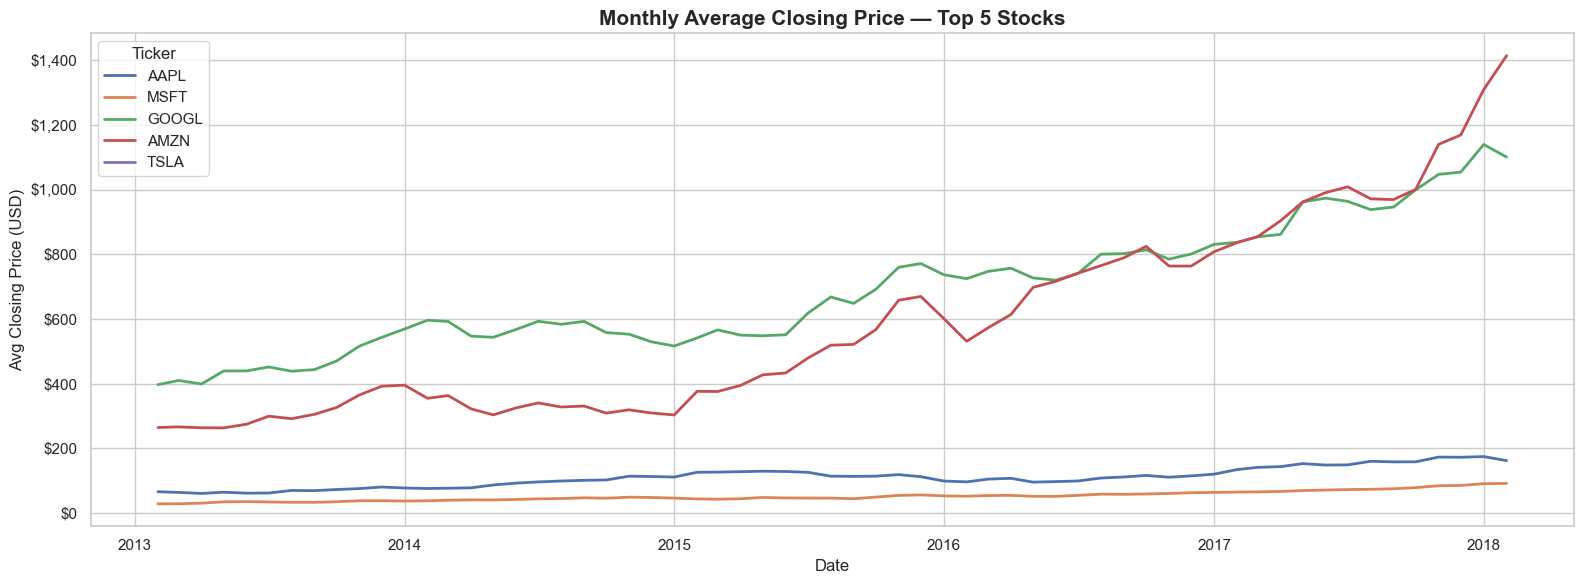

✅ Chart 1 saved!


In [25]:
top_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]
df_top = df[df["ticker"].isin(top_tickers)].copy()
df_top["month"] = df_top["date"].dt.to_period("M").dt.to_timestamp()
monthly_avg = df_top.groupby(["ticker", "month"])["close"].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
for ticker in top_tickers:
    data = monthly_avg[monthly_avg["ticker"] == ticker]
    ax.plot(data["month"], data["close"], label=ticker, linewidth=2)

ax.set_title("Monthly Average Closing Price — Top 5 Stocks", fontsize=15, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Avg Closing Price (USD)")
ax.legend(title="Ticker")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("charts/01_monthly_avg_close.png", dpi=150)
plt.show()
print("✅ Chart 1 saved!")

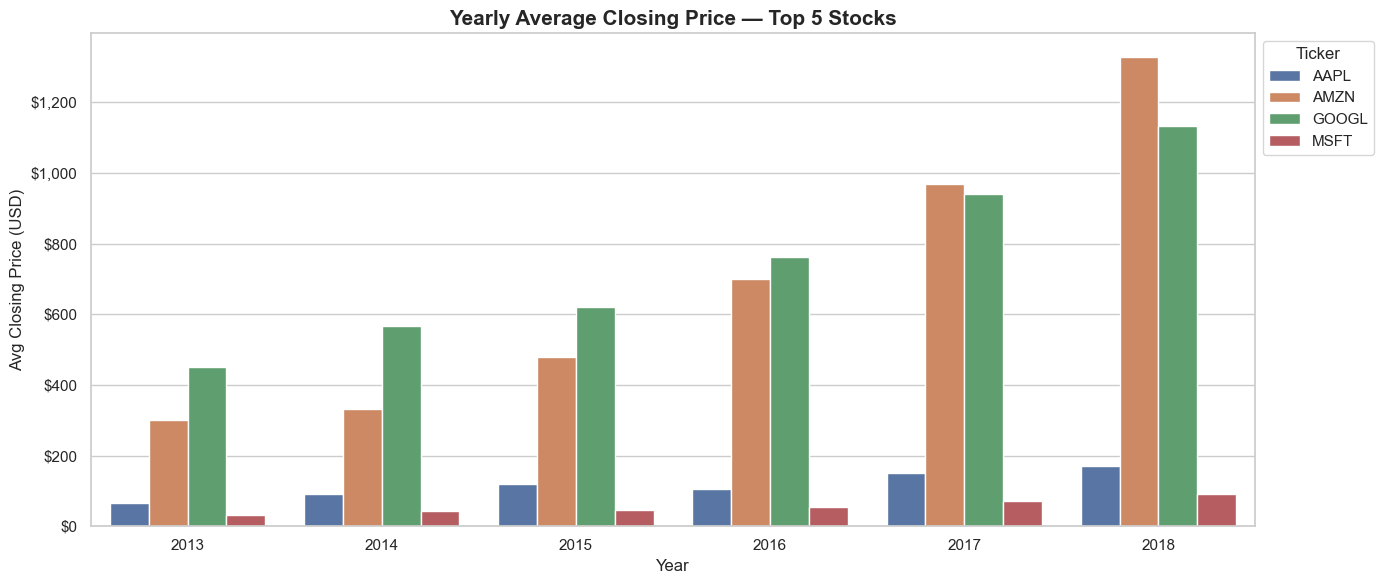

✅ Chart 2 saved!


In [26]:
df_top["year"] = df_top["date"].dt.year
yearly_avg = df_top.groupby(["ticker", "year"])["close"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=yearly_avg, x="year", y="close", hue="ticker", ax=ax)

ax.set_title("Yearly Average Closing Price — Top 5 Stocks",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Avg Closing Price (USD)")
ax.legend(title="Ticker", bbox_to_anchor=(1, 1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("charts/02_yearly_avg_close.png", dpi=150)
plt.show()
print("✅ Chart 2 saved!")

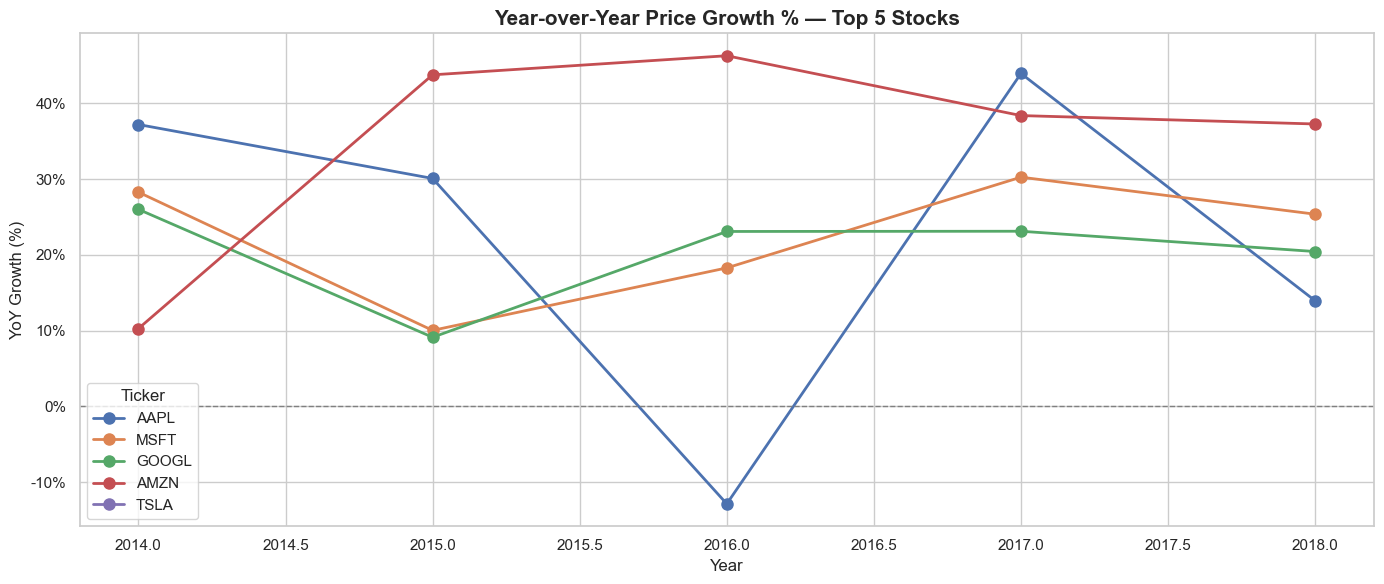

✅ Chart 3 saved!


In [27]:
yearly_avg["prev_close"] = yearly_avg.groupby("ticker")["close"].shift(1)
yearly_avg["yoy_growth"] = ((yearly_avg["close"] - yearly_avg["prev_close"])
                             / yearly_avg["prev_close"] * 100).round(2)
yearly_avg_clean = yearly_avg.dropna(subset=["yoy_growth"])

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in top_tickers:
    data = yearly_avg_clean[yearly_avg_clean["ticker"] == ticker]
    ax.plot(data["year"], data["yoy_growth"], marker="o", label=ticker, linewidth=2, markersize=8)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Year-over-Year Price Growth % — Top 5 Stocks",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("YoY Growth (%)")
ax.legend(title="Ticker")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig("charts/03_yoy_growth.png", dpi=150)
plt.show()
print("✅ Chart 3 saved!")

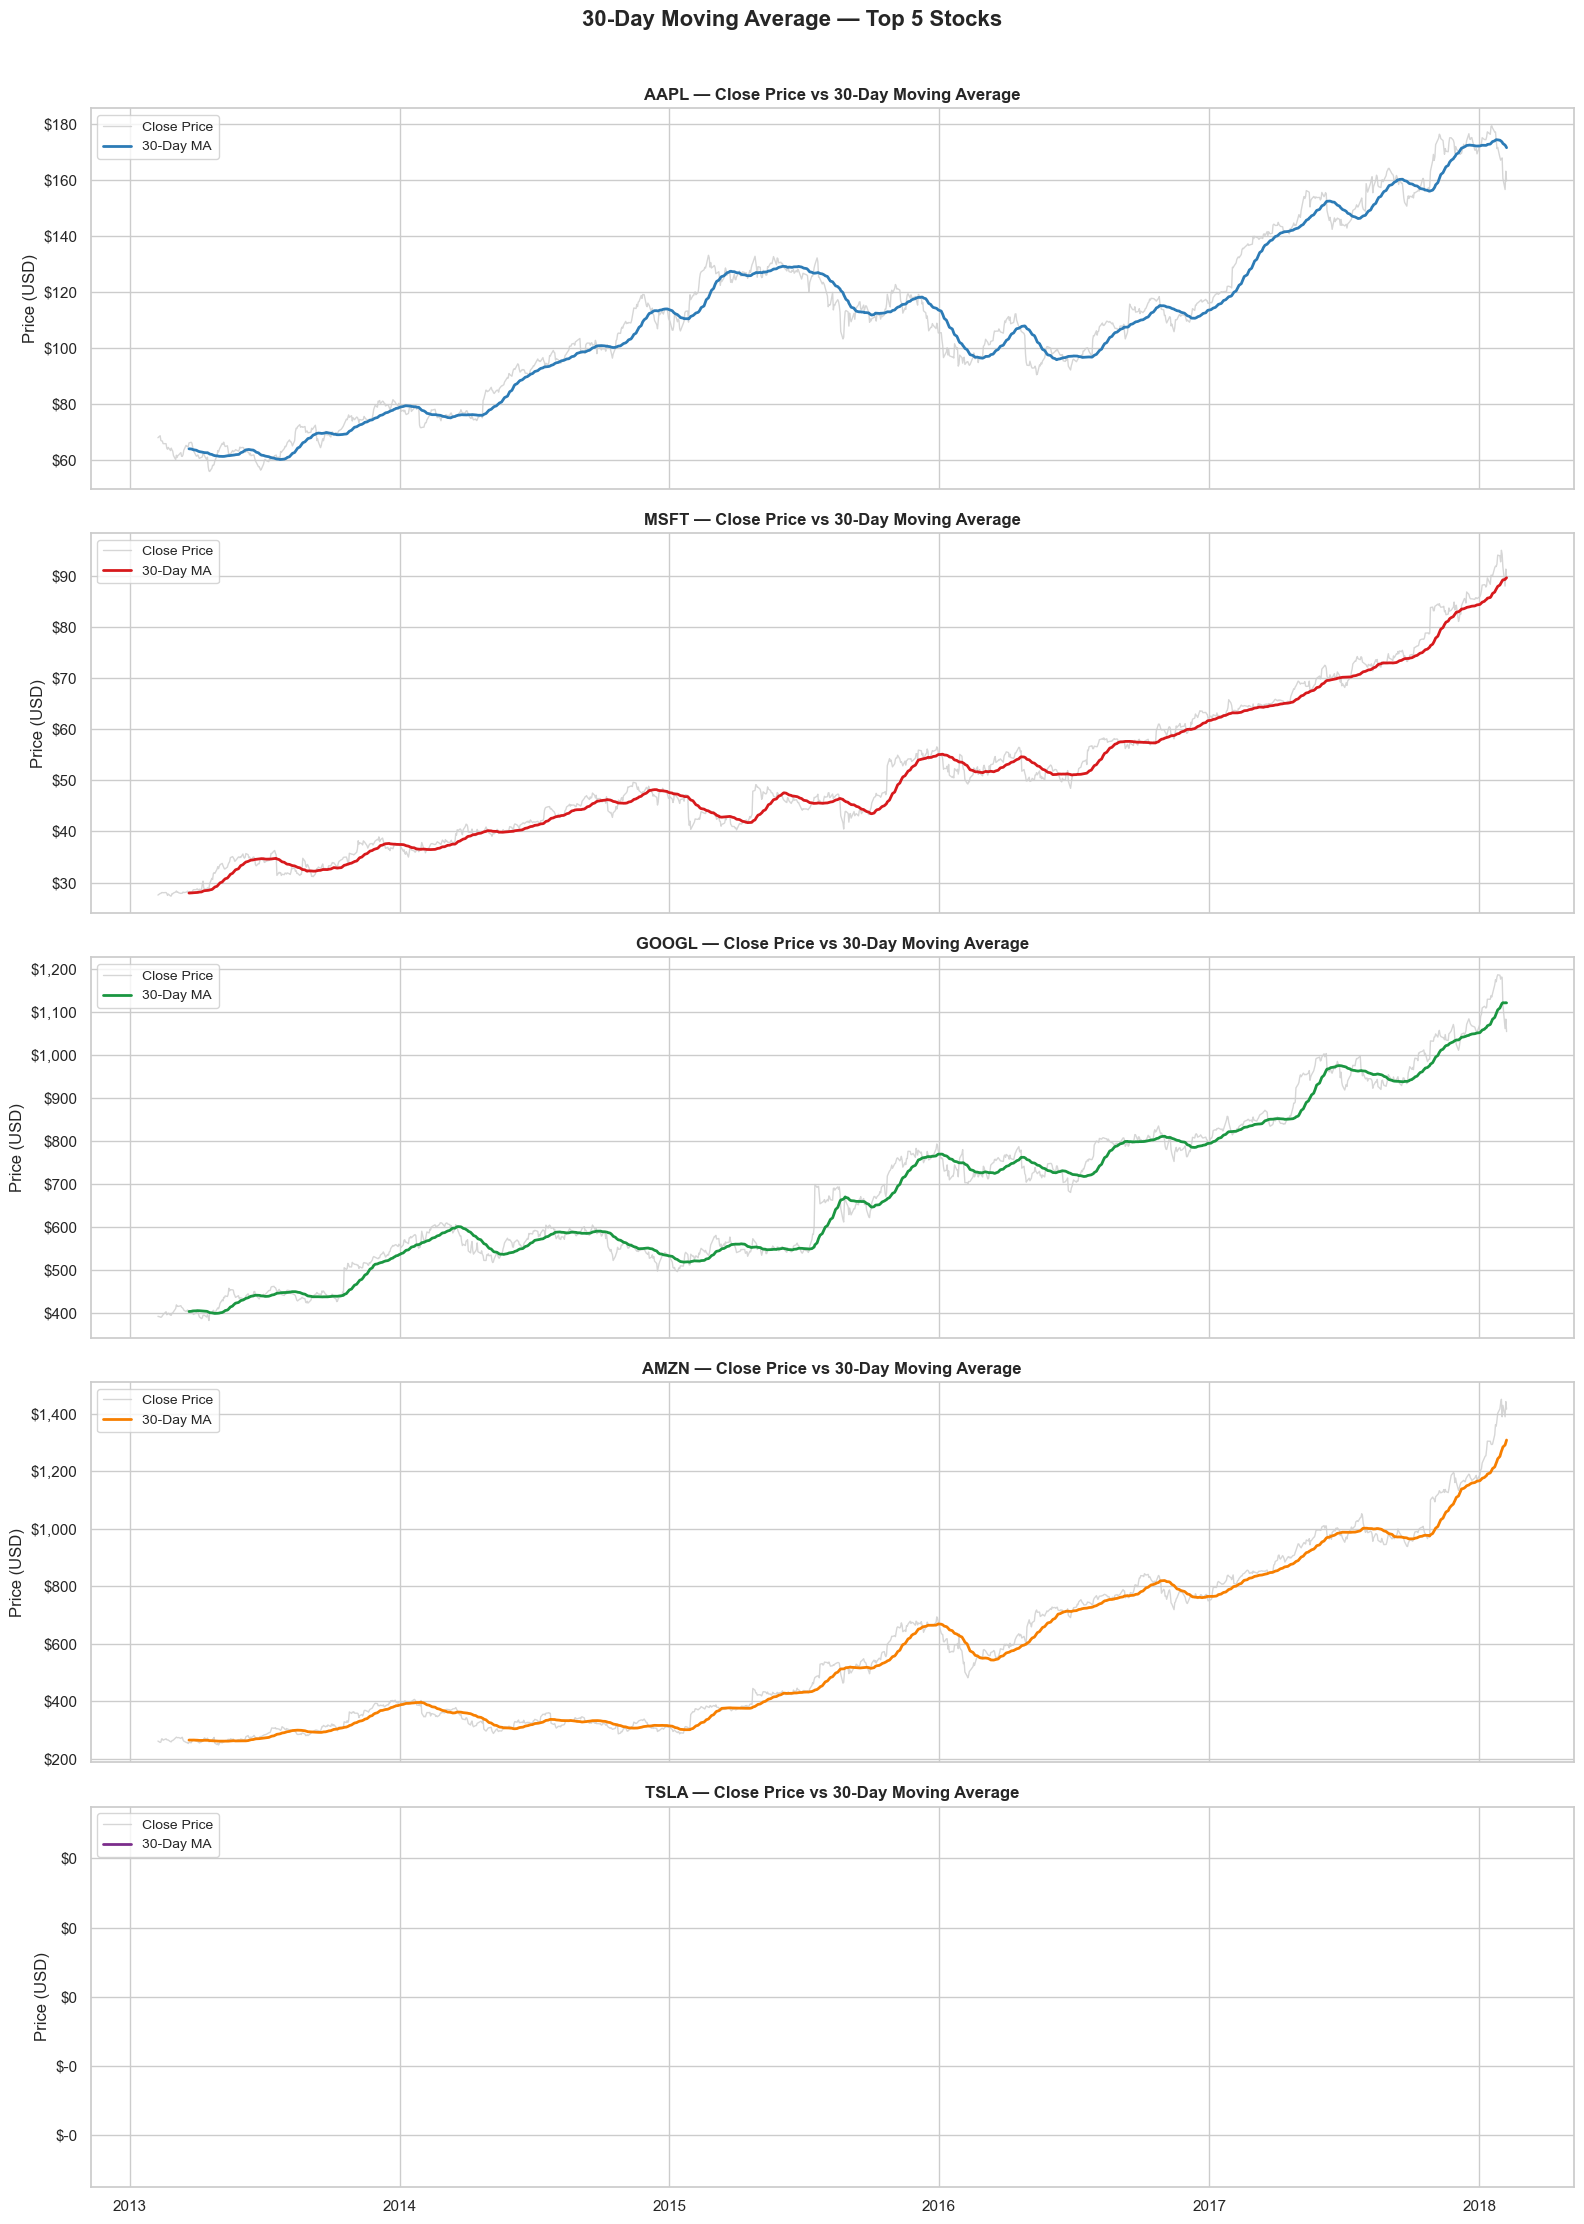

✅ Chart 4 saved!


In [28]:
df_top = df_top.sort_values(["ticker", "date"])
df_top["ma_30"] = df_top.groupby("ticker")["close"].transform(
    lambda x: x.rolling(window=30).mean()
)

colors = ["#2c7bb6", "#d7191c", "#1a9641", "#f77f00", "#7b2d8b"]

fig, axes = plt.subplots(5, 1, figsize=(16, 22), sharex=True)

for i, ticker in enumerate(top_tickers):
    data = df_top[df_top["ticker"] == ticker]
    axes[i].plot(data["date"], data["close"],
                 color="#cccccc", linewidth=1, alpha=0.8, label="Close Price")
    axes[i].plot(data["date"], data["ma_30"],
                 color=colors[i], linewidth=2, label="30-Day MA")
    axes[i].set_title(f"{ticker} — Close Price vs 30-Day Moving Average",
                      fontweight="bold", fontsize=12)
    axes[i].set_ylabel("Price (USD)")
    axes[i].legend(loc="upper left", fontsize=10)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.suptitle("30-Day Moving Average — Top 5 Stocks",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("charts/04_moving_average.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved!")

In [29]:
check = ["AAPL", "MSFT", "GOOGL", "AMZN", "NFLX"]
for t in check:
    exists = t in df["ticker"].unique()
    print(f"{t}: {'✅ Available' if exists else '❌ Not in dataset'}")

AAPL: ✅ Available
MSFT: ✅ Available
GOOGL: ✅ Available
AMZN: ✅ Available
NFLX: ✅ Available


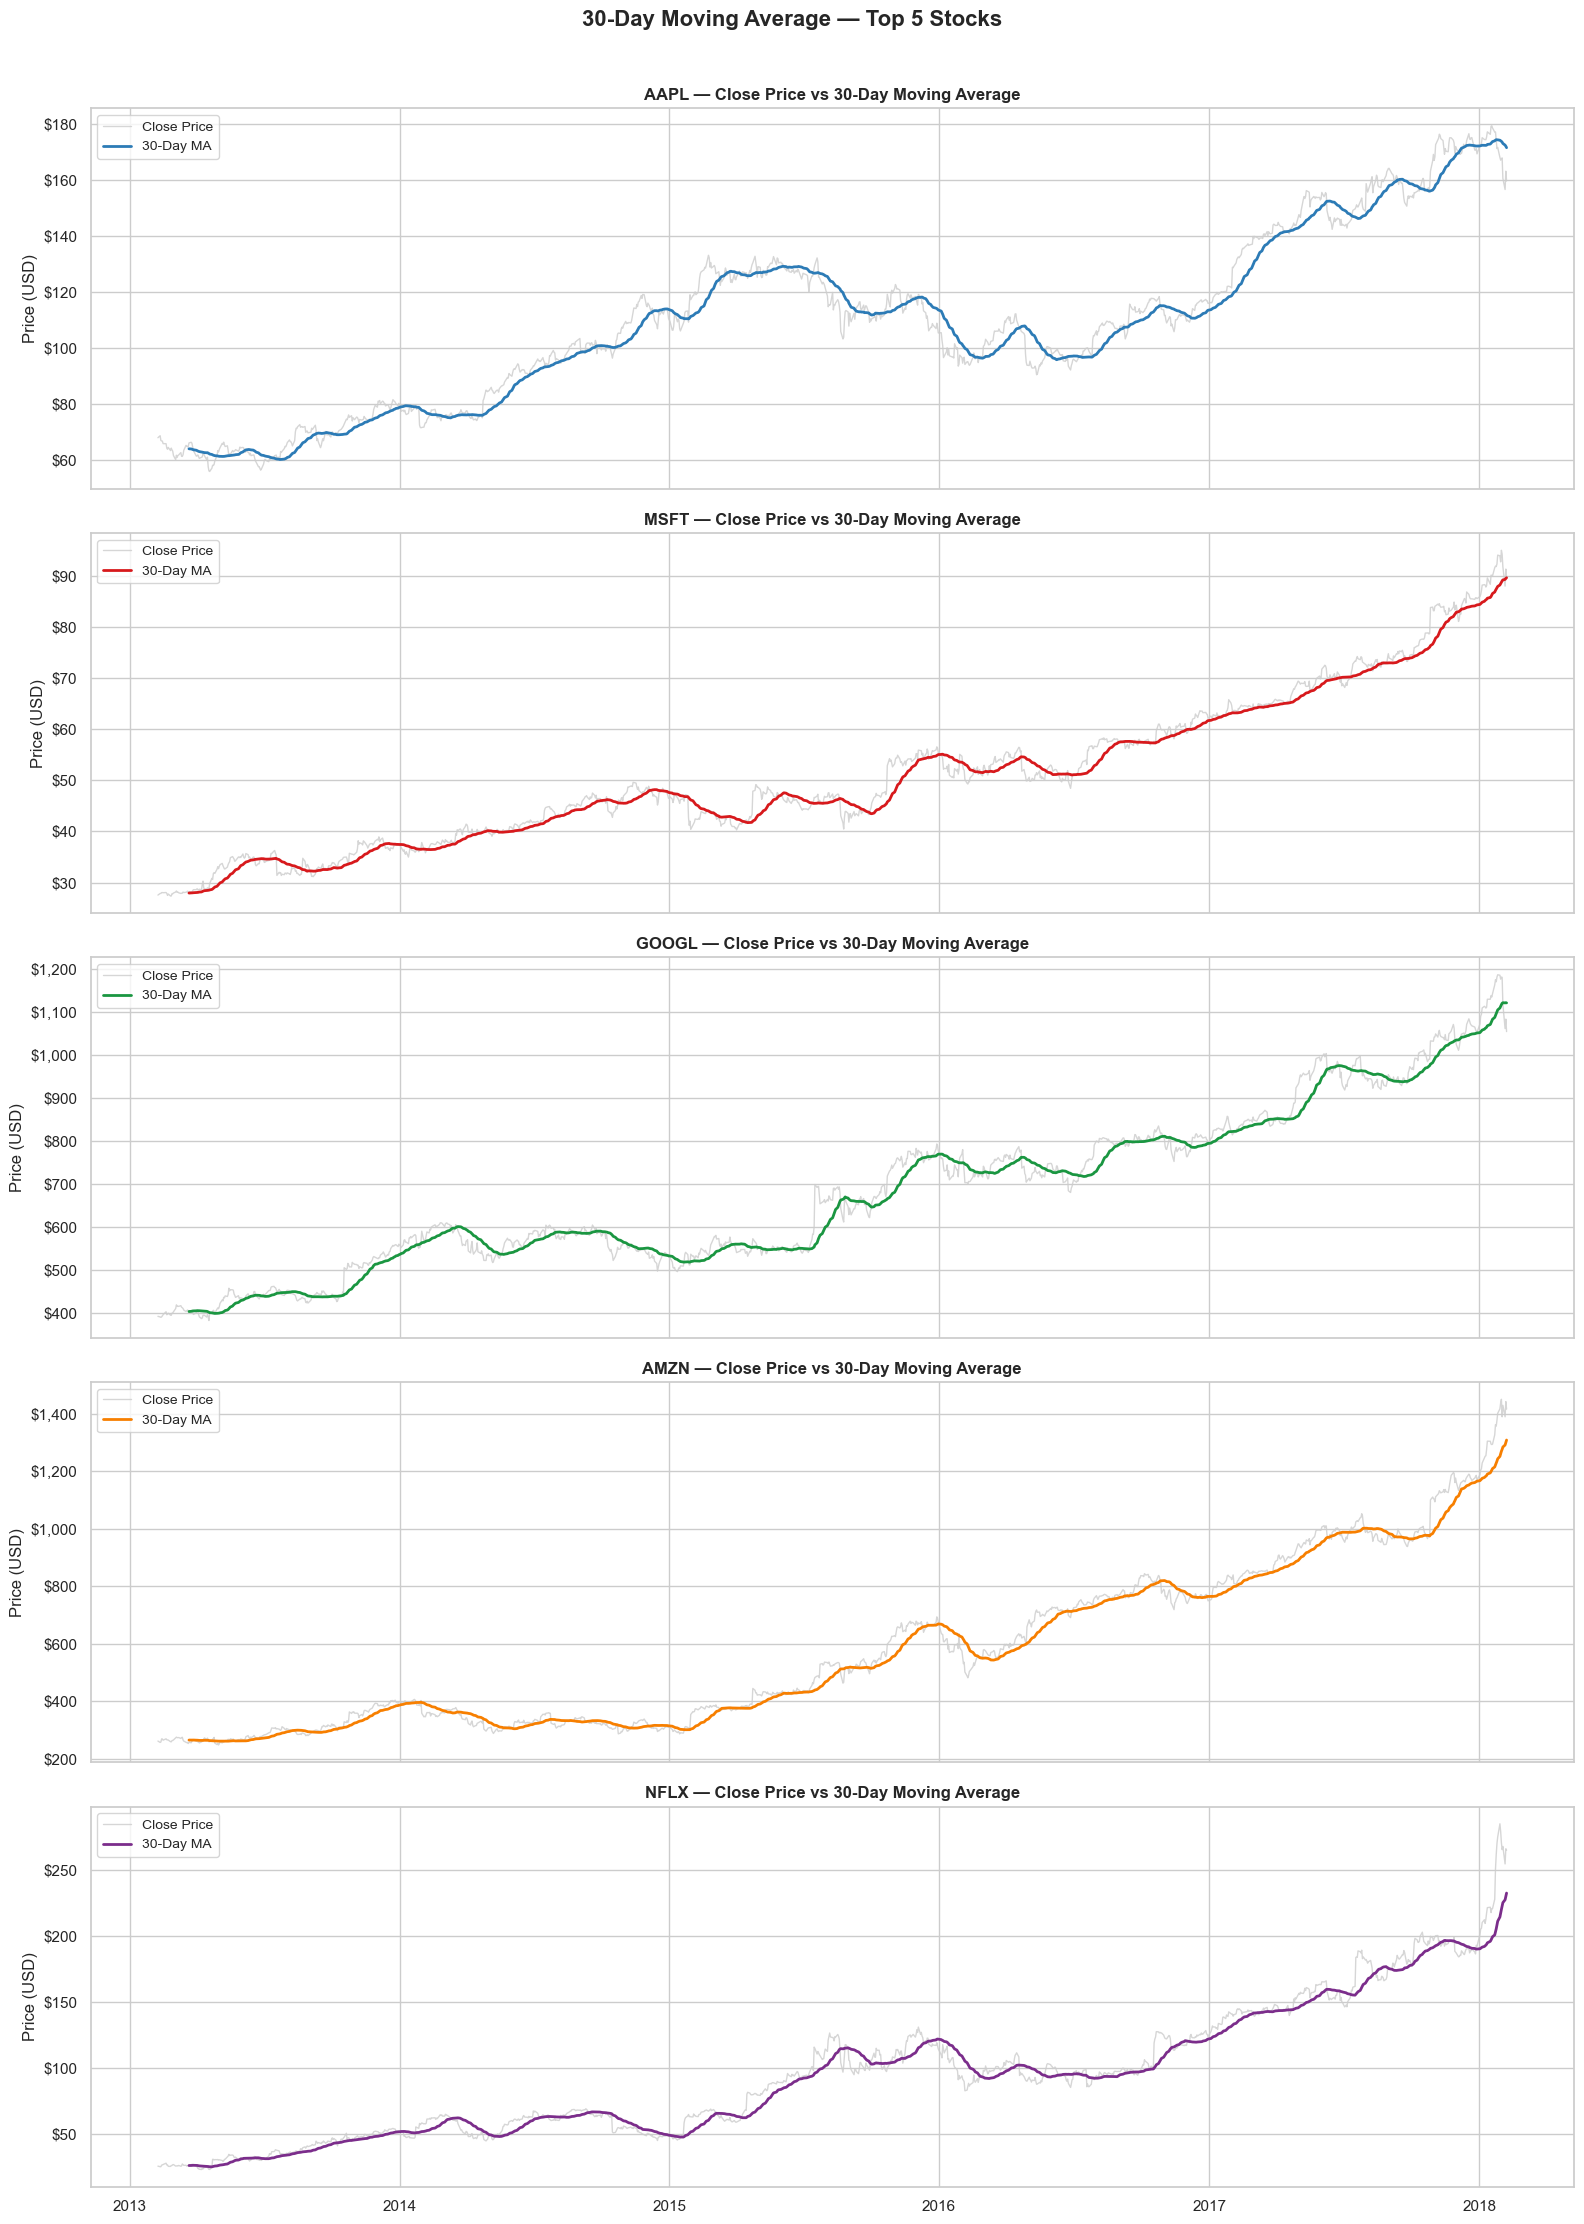

✅ Chart 4 saved!


In [30]:
# Replace TSLA with NFLX
top_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NFLX"]

# Rerun the data filter
df_top = df[df["ticker"].isin(top_tickers)].copy()
df_top["month"] = df_top["date"].dt.to_period("M").dt.to_timestamp()
df_top["year"] = df_top["date"].dt.year

# Recalculate moving average
df_top = df_top.sort_values(["ticker", "date"])
df_top["ma_30"] = df_top.groupby("ticker")["close"].transform(
    lambda x: x.rolling(window=30).mean()
)

colors = ["#2c7bb6", "#d7191c", "#1a9641", "#f77f00", "#7b2d8b"]

fig, axes = plt.subplots(5, 1, figsize=(16, 22), sharex=True)

for i, ticker in enumerate(top_tickers):
    data = df_top[df_top["ticker"] == ticker]
    axes[i].plot(data["date"], data["close"],
                 color="#cccccc", linewidth=1, alpha=0.8, label="Close Price")
    axes[i].plot(data["date"], data["ma_30"],
                 color=colors[i], linewidth=2, label="30-Day MA")
    axes[i].set_title(f"{ticker} — Close Price vs 30-Day Moving Average",
                      fontweight="bold", fontsize=12)
    axes[i].set_ylabel("Price (USD)")
    axes[i].legend(loc="upper left", fontsize=10)
    axes[i].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.suptitle("30-Day Moving Average — Top 5 Stocks",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("charts/04_moving_average.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved!")

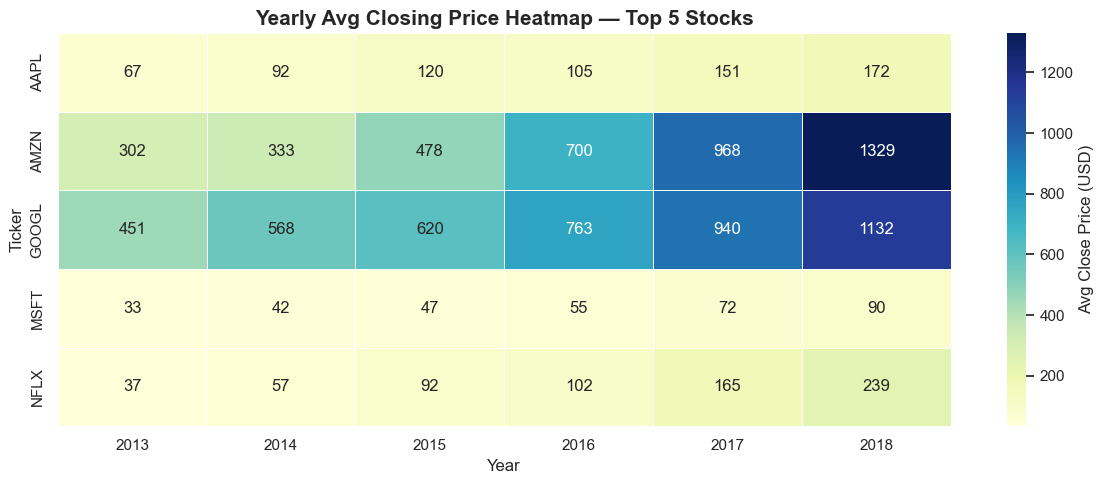

✅ Chart 5 saved!


In [31]:
# Recalculate yearly average with updated tickers
top_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NFLX"]
df_top = df[df["ticker"].isin(top_tickers)].copy()
df_top["year"] = df_top["date"].dt.year
yearly_avg = df_top.groupby(["ticker", "year"])["close"].mean().reset_index()

# Create pivot table
pivot = yearly_avg.pivot(index="ticker", columns="year", values="close")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Avg Close Price (USD)"}
)

ax.set_title("Yearly Avg Closing Price Heatmap — Top 5 Stocks",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Ticker")
plt.tight_layout()
plt.savefig("charts/05_yearly_heatmap.png", dpi=150)
plt.show()
print("✅ Chart 5 saved!")